<a href="https://colab.research.google.com/github/NidhiDekate/car-price-multimodal-dl/blob/main/06_multimodal_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import random
import pickle
import scipy.io
import shutil

from sklearn.metrics import r2_score

# paths
base      = '/content/drive/MyDrive/CarPricePrediction/'
local_img = '/content/cars_train/'

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# load tabular splits - from notebook 03 (perfectly aligned)
X_train = np.load(base + 'data/tabular/X_train.npy')
X_val   = np.load(base + 'data/tabular/X_val.npy')
X_test  = np.load(base + 'data/tabular/X_test.npy')
y_train = np.load(base + 'data/tabular/y_train.npy')
y_val   = np.load(base + 'data/tabular/y_val.npy')
y_test  = np.load(base + 'data/tabular/y_test.npy')

# load df_final - aligned with numpy arrays via split column
df_final = pd.read_csv(base + 'data/tabular/df_final.csv')
train_df = df_final[df_final['split'] == 'train'].reset_index(drop=True)
val_df   = df_final[df_final['split'] == 'val'].reset_index(drop=True)
test_df  = df_final[df_final['split'] == 'test'].reset_index(drop=True)

print(f"train: {len(train_df)}  X_train: {X_train.shape[0]}  match: {len(train_df)==X_train.shape[0]}")
print(f"val:   {len(val_df)}    X_val:   {X_val.shape[0]}    match: {len(val_df)==X_val.shape[0]}")
print(f"test:  {len(test_df)}   X_test:  {X_test.shape[0]}   match: {len(test_df)==X_test.shape[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
train: 28321  X_train: 28321  match: True
val:   6050    X_val:   6050    match: True
test:  6066   X_test:  6066   match: True


In [ ]:
# copy images to local disk
if not os.path.exists(local_img):
    print("copying images...")
    shutil.copytree(base + 'data/images/cars_train/cars_train/', local_img)
    print("done!")
else:
    print("images already on local disk")

# build class→image lookup
img_dir     = base + 'data/images/'
devkit_path = img_dir + 'car_devkit/'

meta        = scipy.io.loadmat(devkit_path + 'devkit/cars_meta.mat')
class_names = [str(c[0]) for c in meta['class_names'][0]]

train_annos = scipy.io.loadmat(devkit_path + 'devkit/cars_train_annos.mat')

class_to_images = {}
for anno in train_annos['annotations'][0]:
    class_idx = int(anno[4][0][0])
    filename  = str(anno[5][0])
    img_path  = local_img + filename
    if class_idx not in class_to_images:
        class_to_images[class_idx] = []
    class_to_images[class_idx].append(img_path)

classname_to_images = {}
for class_idx, img_paths in class_to_images.items():
    name = class_names[class_idx - 1]
    classname_to_images[name] = img_paths

print(f"classes mapped: {len(classname_to_images)}")
print(f"images on disk: {len(os.listdir(local_img))}")

images already on local disk
classes mapped: 196
images on disk: 8144


In [ ]:
class MultimodalDataset(Dataset):
    def __init__(self, df, X_tabular, y_labels, classname_to_images, transform=None):
        self.df                  = df.reset_index(drop=True)
        self.X_tabular           = X_tabular
        self.y_labels            = y_labels
        self.classname_to_images = classname_to_images
        self.transform           = transform
        self.length              = min(len(df), len(X_tabular))

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # tabular
        tabular = torch.tensor(self.X_tabular[idx], dtype=torch.float32)
        price   = torch.tensor(self.y_labels[idx],  dtype=torch.float32)

        # image
        class_name = self.df.iloc[idx]['stanford_class']
        img_path   = random.choice(self.classname_to_images[class_name])
        image      = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, tabular, price

print("MultimodalDataset defined")

MultimodalDataset defined


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = MultimodalDataset(train_df, X_train, y_train, classname_to_images, train_transform)
val_dataset   = MultimodalDataset(val_df,   X_val,   y_val,   classname_to_images, val_transform)
test_dataset  = MultimodalDataset(test_df,  X_test,  y_test,  classname_to_images, val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# verify one sample
image, tabular, price = train_dataset[0]
print(f"image shape:   {image.shape}")
print(f"tabular shape: {tabular.shape}")
print(f"price:         {price.item():.4f}")
print(f"train batches: {len(train_loader)}")

image shape:   torch.Size([3, 224, 224])
tabular shape: torch.Size([12])
price:         10.3056
train batches: 443


## Multimodal fusion — late fusion architecture

Image [3×224×224] → ResNet18 (frozen) → 512 features ──┐  
Tabular [12] → ANN (12→64→32) → 32 features ───────────┴──► concat [544] → Linear(544→256) → ReLU → Linear(256→64) → ReLU → Linear(64→1) → price

**Trainable:** 158,945 params (tabular branch + fusion head)  
**Frozen:** 11.1M params (ResNet18 backbone)

In [ ]:
class MultimodalModel(nn.Module):
    def __init__(self, tabular_dim=12):
        super(MultimodalModel, self).__init__()

        # --- IMAGE BRANCH (CNN) ---
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        # freeze all resnet layers
        for param in backbone.parameters():
            param.requires_grad = False
        # remove final classification layer
        self.image_branch = nn.Sequential(*list(backbone.children())[:-1])

        # --- TABULAR BRANCH (ANN) ---
        self.tabular_branch = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # --- FUSION HEAD ---
        # image branch outputs 512, tabular branch outputs 32
        # concatenate → 544 combined features
        self.fusion_head = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, image, tabular):
        # image path
        img_features = self.image_branch(image)
        img_features = img_features.squeeze(-1).squeeze(-1)  # [B, 512]

        # tabular path
        tab_features = self.tabular_branch(tabular)           # [B, 32]

        # late fusion - concatenate both
        combined = torch.cat([img_features, tab_features], dim=1)  # [B, 544]

        # predict price
        out = self.fusion_head(combined)                       # [B, 1]
        return out


model = MultimodalModel(tabular_dim=12).to(device)

# count params
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total params:     {total:,}")
print(f"trainable params: {trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 79.0MB/s]


total params:     11,335,457
trainable params: 158,945


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for images, tabular, prices in loader:
        images  = images.to(device)
        tabular = tabular.to(device)
        prices  = prices.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(images, tabular)
        loss  = criterion(preds, prices)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, tabular, prices in loader:
            images  = images.to(device)
            tabular = tabular.to(device)
            prices  = prices.to(device).unsqueeze(1)

            preds      = model(images, tabular)
            loss       = criterion(preds, prices)
            total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

print("training functions defined")

training functions defined


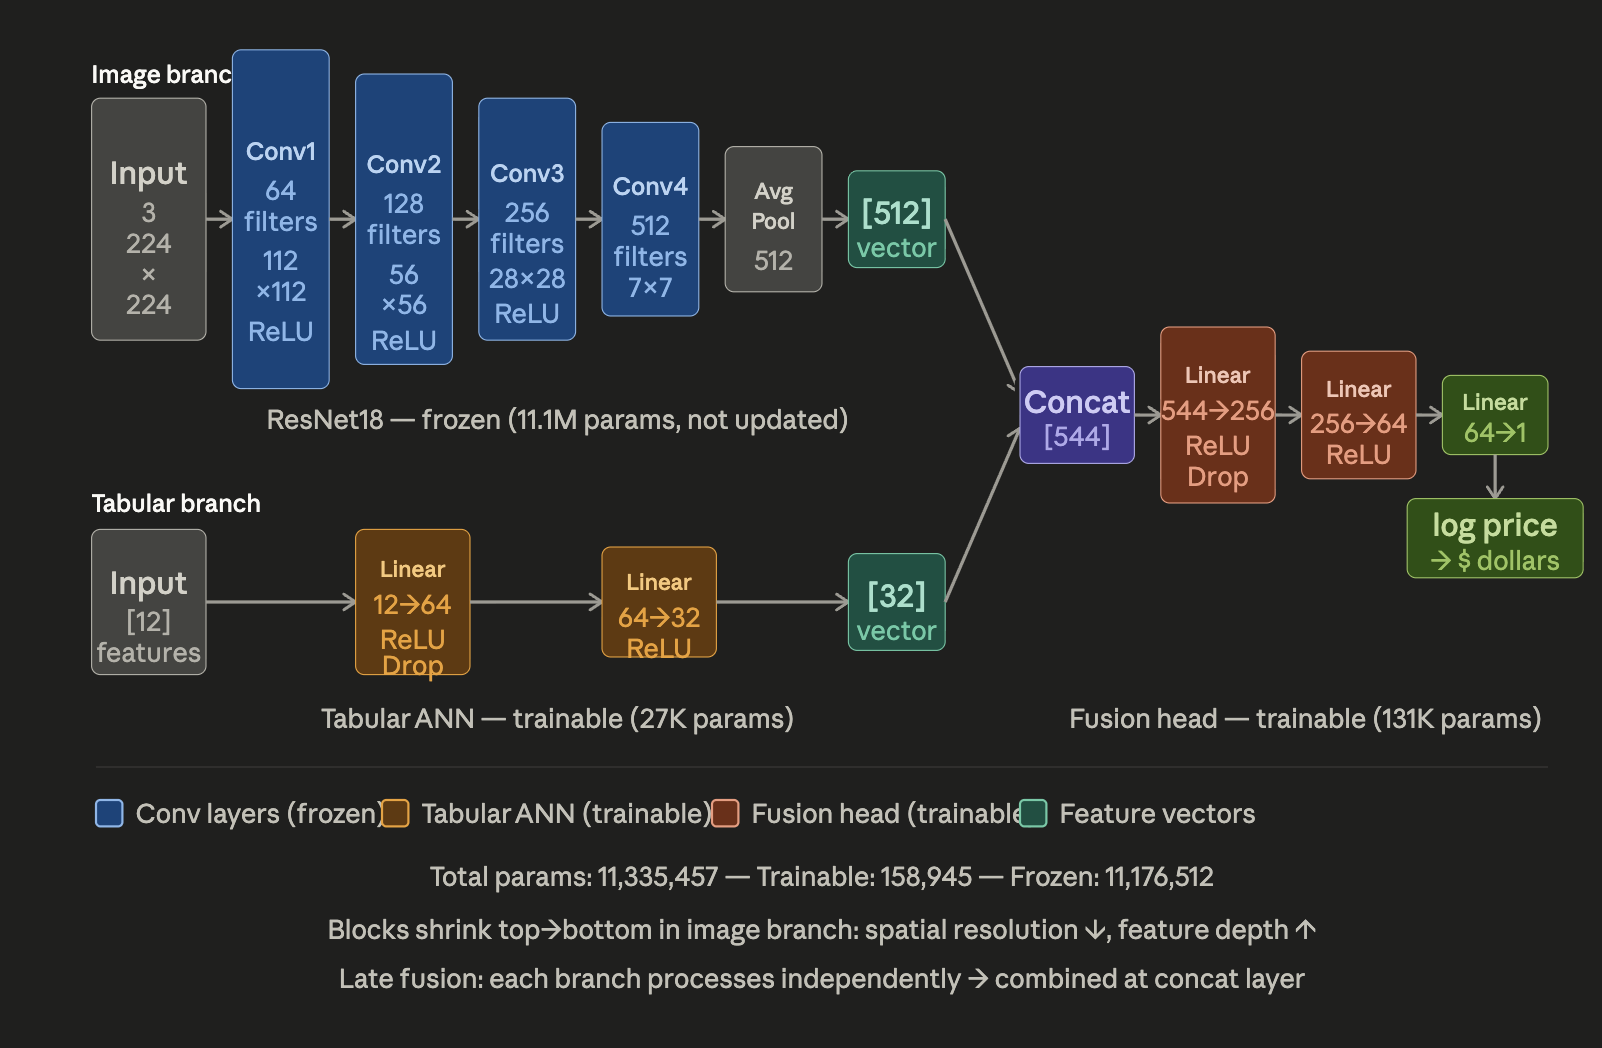

In [ ]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

epochs       = 20
best_val     = float('inf')
train_losses = []
val_losses   = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), base + 'models/multimodal_best.pth')
        tag = '  ← best'
    else:
        tag = ''

    print(f"epoch {epoch:02d}/{epochs}  train: {train_loss:.4f}  val: {val_loss:.4f}{tag}")

print(f"\ntraining done — best val loss: {best_val:.4f}")

epoch 01/20  train: 2.0909  val: 0.4570  ← best
epoch 02/20  train: 0.7100  val: 0.3417  ← best
epoch 03/20  train: 0.6554  val: 0.3126  ← best
epoch 04/20  train: 0.5866  val: 0.3237
epoch 05/20  train: 0.5576  val: 0.7261
epoch 06/20  train: 0.5007  val: 0.9431
epoch 07/20  train: 0.4018  val: 2.2418
epoch 08/20  train: 0.3223  val: 2.8763
epoch 09/20  train: 0.2882  val: 3.2515
epoch 10/20  train: 0.2643  val: 3.7418
epoch 11/20  train: 0.2396  val: 3.8151
epoch 12/20  train: 0.2165  val: 4.2242
epoch 13/20  train: 0.2117  val: 4.4623
epoch 14/20  train: 0.2043  val: 4.2142
epoch 15/20  train: 0.2008  val: 4.4189
epoch 16/20  train: 0.1925  val: 4.6835
epoch 17/20  train: 0.1882  val: 4.3033
epoch 18/20  train: 0.1857  val: 4.6059
epoch 19/20  train: 0.1837  val: 4.5169
epoch 20/20  train: 0.1792  val: 4.9122

training done — best val loss: 0.3126


In [ ]:
model = MultimodalModel(tabular_dim=12).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

epochs        = 30
best_val      = float('inf')
patience      = 5
no_improve    = 0
train_losses  = []
val_losses    = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        no_improve = 0
        torch.save(model.state_dict(), base + 'models/multimodal_best.pth')
        tag = '  ← best'
    else:
        no_improve += 1
        tag = f'  (no improve {no_improve}/{patience})'

    print(f"epoch {epoch:02d}/{epochs}  train: {train_loss:.4f}  val: {val_loss:.4f}{tag}")

    if no_improve >= patience:
        print(f"\nearly stopping at epoch {epoch}")
        break

print(f"\ntraining done — best val loss: {best_val:.4f}")

epoch 01/30  train: 2.0851  val: 0.7298  ← best
epoch 02/30  train: 0.7468  val: 0.6074  ← best
epoch 03/30  train: 0.6721  val: 0.3287  ← best
epoch 04/30  train: 0.6150  val: 0.4761  (no improve 1/5)
epoch 05/30  train: 0.5431  val: 1.1621  (no improve 2/5)
epoch 06/30  train: 0.4384  val: 2.3859  (no improve 3/5)
epoch 07/30  train: 0.3257  val: 2.9885  (no improve 4/5)
epoch 08/30  train: 0.2883  val: 3.8626  (no improve 5/5)

early stopping at epoch 8

training done — best val loss: 0.3287


In [ ]:
# load best weights
model.load_state_dict(torch.load(base + 'models/multimodal_best.pth'))
model.eval()

all_preds  = []
all_actual = []

with torch.no_grad():
    for images, tabular, prices in val_loader:
        images  = images.to(device)
        tabular = tabular.to(device)
        preds   = model(images, tabular).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_actual.extend(prices.numpy())

all_preds  = np.expm1(np.array(all_preds))
all_actual = np.expm1(np.array(all_actual))

rmse = np.sqrt(np.mean((all_preds - all_actual) ** 2))
r2   = r2_score(all_actual, all_preds)

print(f"multimodal val RMSE: ${rmse:,.0f}")
print(f"multimodal val R²:   {r2:.4f}")
print()
print("── comparison ──────────────────────")
print(f"XGBoost only:   RMSE=$1,872   R²=0.9500")
print(f"CNN only:       RMSE=$10,454  R²=-0.4912")
print(f"Multimodal:     RMSE=${rmse:,.0f}   R²={r2:.4f}")

multimodal val RMSE: $8,772
multimodal val R²:   -0.0990

── comparison ──────────────────────
XGBoost only:   RMSE=$1,872   R²=0.9500
CNN only:       RMSE=$10,454  R²=-0.4912
Multimodal:     RMSE=$8,772   R²=-0.0990


## Training strategy — progressive unfreezing

**Problem:** Frozen ResNet cannot adapt to our data.

**Solution:** Unfreeze last ResNet block (layer4) with differential learning rates.

| Layer | Learning rate | Why |
|---|---|---|
| ResNet layer1–3 | frozen | edges/shapes already learned |
| ResNet layer4 | 1e-4 small | gently adapt to car features |
| Tabular ANN | 1e-3 normal | learn odometer/condition |
| Fusion head | 1e-3 normal | combine both signals |

Early stopping patience=5 — best weights saved automatically.

**Why small lr for ResNet layer4?**  
ResNet already has good ImageNet weights. Large updates destroy that knowledge.  
Small updates let it gently specialize for car price features.

**Why unfreeze only layer4?**  
Early layers detect universal features (edges, textures) — no need to change.  
Deep layers detect high-level semantics — these can specialize for cars.

**Early stopping:** patience=5 — stops when val loss doesn't improve for 5 epochs.  
Best model weights saved automatically at each improvement.

In [ ]:
# reload fresh model
model = MultimodalModel(tabular_dim=12).to(device)

# unfreeze only the last resnet block (layer4)
for name, param in model.named_parameters():
    if 'image_branch.7' in name:  # layer4 in resnet18
        param.requires_grad = True

# check trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {trainable:,}")

# differential learning rates
# lower lr for resnet layers, higher for our custom layers
optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters()
                if 'image_branch.7' in n and p.requires_grad],
     'lr': 1e-4},   # small lr for resnet layers
    {'params': [p for n, p in model.named_parameters()
                if 'image_branch.7' not in n and p.requires_grad],
     'lr': 1e-3},   # normal lr for our layers
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

epochs      = 30
best_val    = float('inf')
no_improve  = 0
patience    = 5
train_losses = []
val_losses   = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        no_improve = 0
        torch.save(model.state_dict(), base + 'models/multimodal_best.pth')
        tag = '  ← best'
    else:
        no_improve += 1
        tag = f'  (no improve {no_improve}/{patience})'

    print(f"epoch {epoch:02d}/{epochs}  train: {train_loss:.4f}  val: {val_loss:.4f}{tag}")

    if no_improve >= patience:
        print(f"\nearly stopping at epoch {epoch}")
        break

print(f"\ntraining done — best val loss: {best_val:.4f}")

trainable params: 8,552,673
epoch 01/30  train: 1.6103  val: 0.2758  ← best
epoch 02/30  train: 0.5044  val: 0.2284  ← best
epoch 03/30  train: 0.4623  val: 0.5823  (no improve 1/5)
epoch 04/30  train: 0.4380  val: 1.1124  (no improve 2/5)
epoch 05/30  train: 0.2798  val: 4.8060  (no improve 3/5)
epoch 06/30  train: 0.2015  val: 4.5376  (no improve 4/5)
epoch 07/30  train: 0.1859  val: 5.3168  (no improve 5/5)

early stopping at epoch 7

training done — best val loss: 0.2284


In [ ]:
# load best weights
model.load_state_dict(torch.load(base + 'models/multimodal_best.pth'))
model.eval()

all_preds  = []
all_actual = []

with torch.no_grad():
    for images, tabular, prices in val_loader:
        images  = images.to(device)
        tabular = tabular.to(device)
        preds   = model(images, tabular).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_actual.extend(prices.numpy())

all_preds  = np.expm1(np.array(all_preds))
all_actual = np.expm1(np.array(all_actual))

rmse = np.sqrt(np.mean((all_preds - all_actual) ** 2))
r2   = r2_score(all_actual, all_preds)

print(f"multimodal val RMSE: ${rmse:,.0f}")
print(f"multimodal val R²:   {r2:.4f}")
print()
print("── final comparison ────────────────")
print(f"XGBoost only:   RMSE=$1,872   R²=0.9500")
print(f"CNN only:       RMSE=$10,454  R²=-0.4912")
print(f"Multimodal v1:  RMSE=$8,772   R²=-0.0990")
print(f"Multimodal v2:  RMSE=${rmse:,.0f}   R²={r2:.4f}")

multimodal val RMSE: $7,892
multimodal val R²:   0.1106

── final comparison ────────────────
XGBoost only:   RMSE=$1,872   R²=0.9500
CNN only:       RMSE=$10,454  R²=-0.4912
Multimodal v1:  RMSE=$8,772   R²=-0.0990
Multimodal v2:  RMSE=$7,892   R²=0.1106


In [ ]:
import pickle

# save final results
results = {
    'cnn_rmse':          10454,
    'cnn_r2':            -0.4912,
    'multimodal_v1_rmse': 8772,
    'multimodal_v1_r2':  -0.0990,
    'multimodal_v2_rmse': rmse,
    'multimodal_v2_r2':   r2,
    'xgboost_rmse':       1872,
    'xgboost_r2':         0.9500,
    'train_losses':       train_losses,
    'val_losses':         val_losses
}

with open(base + 'models/multimodal_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# save final model
torch.save(model.state_dict(), base + 'models/multimodal_final.pth')

print("saved multimodal_results.pkl")
print("saved multimodal_final.pth")
print("")
print("key finding: tabular features dominate price prediction")
print("image signal adds marginal value only when ResNet unfrozen")
print("real improvement needs per-listing unique car photos")


saved multimodal_results.pkl
saved multimodal_final.pth

key finding: tabular features dominate price prediction
image signal adds marginal value only when ResNet unfrozen
real improvement needs per-listing unique car photos
